In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import cv2
import kagglehub
from torchvision import datasets, transforms
import glob
import torch

In [2]:
path = kagglehub.dataset_download("moltean/fruits")


Using Colab cache for faster access to the 'fruits' dataset.


Manually chosen paths for Red apple, Green Apple, Strawberry, Orange & lime

In [3]:
red_apple_paths = glob.glob(f"{path}/fruits-360_100x100/fruits-360/Training/Apple Red 1/*.jpg")
green_apple_paths = glob.glob(f"{path}/fruits-360_100x100/fruits-360/Training/Apple Granny Smith 1/*.jpg")
banana_paths = glob.glob(f"{path}/fruits-360_100x100/fruits-360/Training/Banana 1/*.jpg")
strawberry_paths = glob.glob(f"{path}/fruits-360_100x100/fruits-360/Training/Strawberry 1/*.jpg")
orange_paths = glob.glob(f"{path}/fruits-360_100x100/fruits-360/Training/Orange 1/*.jpg")
lime_paths = glob.glob(f"{path}/fruits-360_100x100/fruits-360/Training/Limes 1/*.jpg")

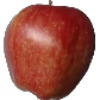

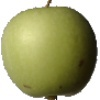

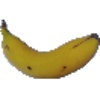

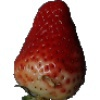

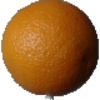

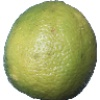

In [4]:
red_apple = cv2.imread(red_apple_paths[2])
green_apple = cv2.imread(green_apple_paths[2])
banana = cv2.imread(banana_paths[2])
strawberry = cv2.imread(strawberry_paths[4])
orange = cv2.imread(orange_paths[6])
lime = cv2.imread(lime_paths[7])

if red_apple | green_apple | banana | strawberry | orange | lime  is not None:
    cv2_imshow(red_apple),
    cv2_imshow(green_apple),
    cv2_imshow(banana),
    cv2_imshow(strawberry),
    cv2_imshow(orange),
    cv2_imshow(lime)
else:
    print("Error: It could not be loaded from the path specified.")

## Visualizing Red Apple with cv2.imshow() and matplotlib

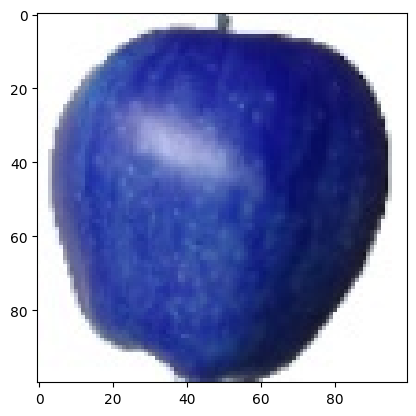

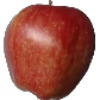

In [5]:
# using matplotlib
plt.imshow(red_apple)
plt.show()

#using cv2.imshow()
cv2_imshow(red_apple)

### Conclusion: Matplotlib displays image in RGB format whereas cv2.imshow() displays image in BGR format

### Converting BGR to RGB to display image in correct color format using matplotlib

## Understanding HSV (Hue, Saturation, Value) Color Format

While RGB (and BGR used by OpenCV) represents color as a combination of Red, Green, and Blue light intensities, the HSV color space offers a different, often more intuitive, way to describe colors, especially useful in image processing tasks.

**Brief Info about HSV:**
*   **Hue (H):** Represents the pure color (e.g., red, green, blue). It's typically measured as an angle from 0 to 360 degrees (or 0-179 in OpenCV for an 8-bit image). It corresponds to the actual color tone.
*   **Saturation (S):** Represents the purity or intensity of the color. A saturation of 0 means the color is a shade of gray, while higher saturation means the color is more vibrant. It ranges from 0 to 100% (or 0-255).
*   **Value (V) / Brightness:** Represents the brightness or luminance of the color. A value of 0 is black, and a value of 100% (or 255) is the brightest possible. It ranges from 0 to 100% (or 0-255).

**Problems without HSV (e.g., in RGB/BGR):**
When working with RGB/BGR images, especially in varying lighting conditions, a single color can have vastly different RGB values. For example, a red apple under bright light will have different RGB components than the same red apple under dim light. This makes tasks like color-based object detection or segmentation challenging, as you'd need to define a wide range of RGB values to cover all possible lighting scenarios for a single color. The intensity (brightness) is intertwined with the color components.

**How HSV Solves This:**
HSV separates color information (Hue) from intensity information (Value/Brightness). This separation is its key advantage:
*   **Hue:** The `Hue` component is relatively stable under different lighting conditions. The actual color tone of an object doesn't change drastically whether it's brightly lit or in shadow. This makes it much easier to identify a specific color regardless of illumination.
*   **Saturation and Value:** These components describe how much of that pure color is present (purity/vibrancy) and how bright it is. You can adjust or analyze these independently of the color tone itself.

By using HSV, you can define color ranges (e.g., for a red apple) much more robustly using primarily the `Hue` channel, making your color detection algorithms more resilient to changes in lighting.

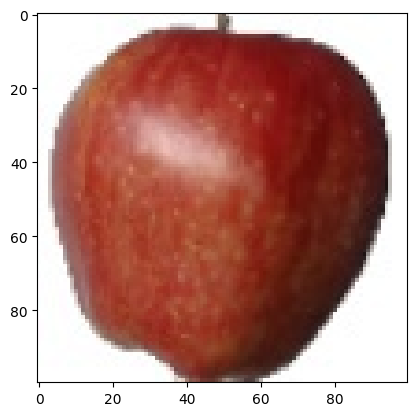

In [6]:
rgb_apple = cv2.cvtColor(red_apple, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_apple)
plt.show()

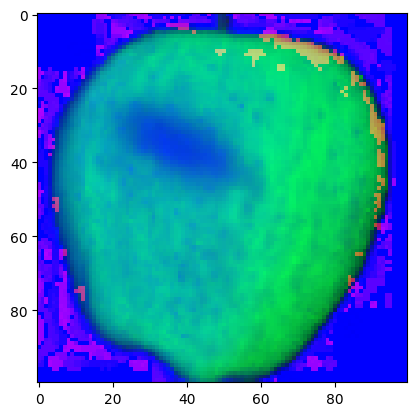

In [7]:
hsv_red_apple = cv2.cvtColor(red_apple, cv2.COLOR_BGR2HSV)
plt.imshow(hsv_red_apple)
plt.show()

In [8]:
# splitting the H, S, V channels
H, S, V = cv2.split(hsv_red_apple)
print(H.shape)
print(S.shape)
print(V.shape)

(100, 100)
(100, 100)
(100, 100)


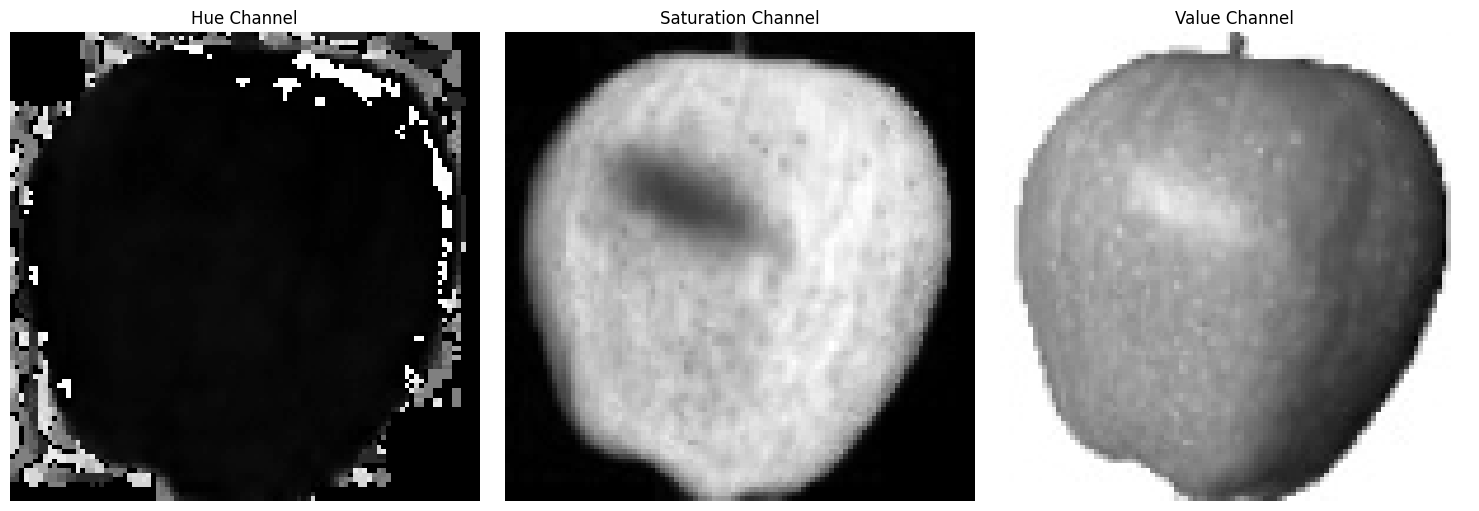

In [9]:
plt.figure(figsize=(15, 5))

# Display Hue channel
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
plt.imshow(H, cmap='gray')
plt.title('Hue Channel')
plt.axis('off')

# Display Saturation channel
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
plt.imshow(S, cmap='gray')
plt.title('Saturation Channel')
plt.axis('off')

# Display Value channel
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
plt.imshow(V, cmap='gray')
plt.title('Value Channel')
plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Maximum and minimum intensity pixel values
print(f"Max Intensity: {S.max()}, Min Intensity: {S.min()}")

Max Intensity: 240, Min Intensity: 0


In [11]:
# masking the image
mask = cv2.inRange(S, 100, 255)
masked_red_apple = cv2.bitwise_and(rgb_apple, rgb_apple, mask=mask)

### Comparing original image, Mask and Masked Image

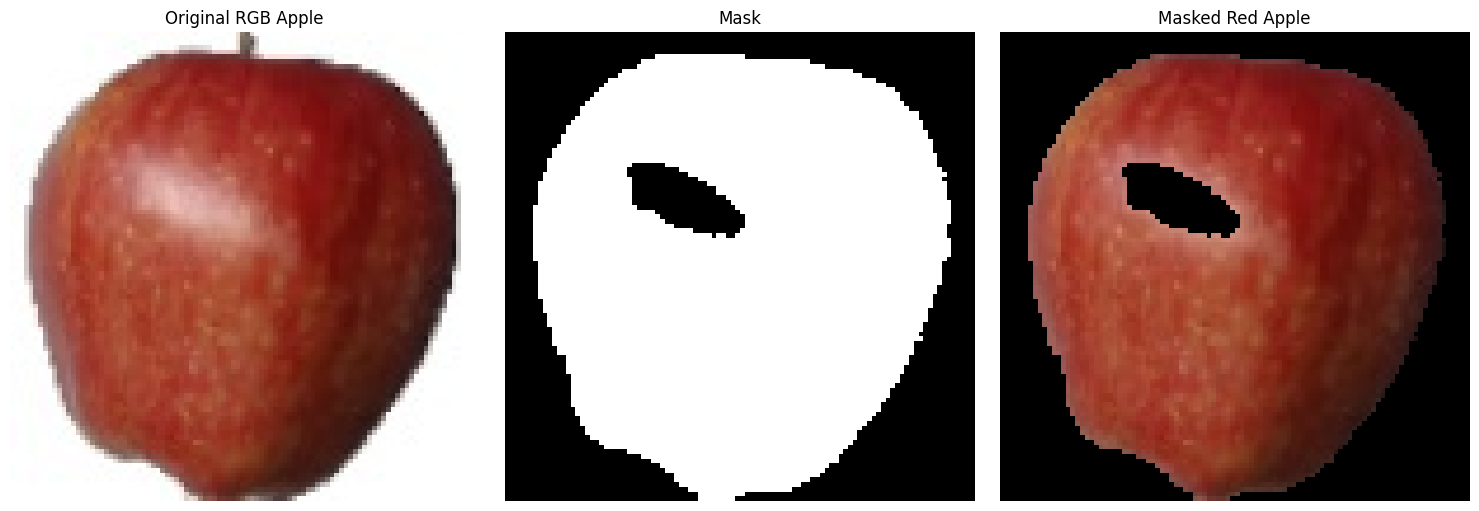

In [12]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
plt.imshow(rgb_apple)
plt.title('Original RGB Apple')
plt.axis('off')

plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
plt.imshow(mask, cmap='gray') # Mask is grayscale
plt.title('Mask')
plt.axis('off')

plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
plt.imshow(masked_red_apple)
plt.title('Masked Red Apple')
plt.axis('off')

plt.tight_layout()
plt.show()

## Standardized HSV Ranges for Fruits (Approximation)

These ranges represent typical values for the dominant colors of the fruits in the HSV color space, using OpenCV's 0-179 for Hue and 0-255 for Saturation and Value. These are more refined than the min/max values observed from the full images (which included white backgrounds) and are suitable for color-based masking.

| Fruit        | Hue (H) (0-179)     | Saturation (S) (0-255) | Value (V) (0-255)   |
| :----------- | :------------------ | :--------------------- | :------------------ |
| **Red Apple**  | [0-10] and [170-179]| [100-255]              | [50-255]            |
| **Green Apple**| [35-70]             | [100-255]              | [50-255]            |
| **Banana**   | [15-30]             | [100-255]              | [100-255]           |
| **Strawberry** | [0-10] and [170-179]| [100-255]              | [50-255]            |
| **Lime**     | [45-75]             | [100-255]              | [50-255]            |

**Notes:**
*   **Hue (H):** Red often appears in two segments because the color wheel wraps around. Yellows are typically around 20-30, greens around 40-70.
*   **Saturation (S):** A higher minimum value (e.g., 100) helps exclude grayish or desaturated areas (like backgrounds or reflections).
*   **Value (V):** A minimum value (e.g., 50 or 100) helps exclude very dark shadows while the maximum allows for bright areas.

Masking Green apple, Banana, Strawberry, Lime

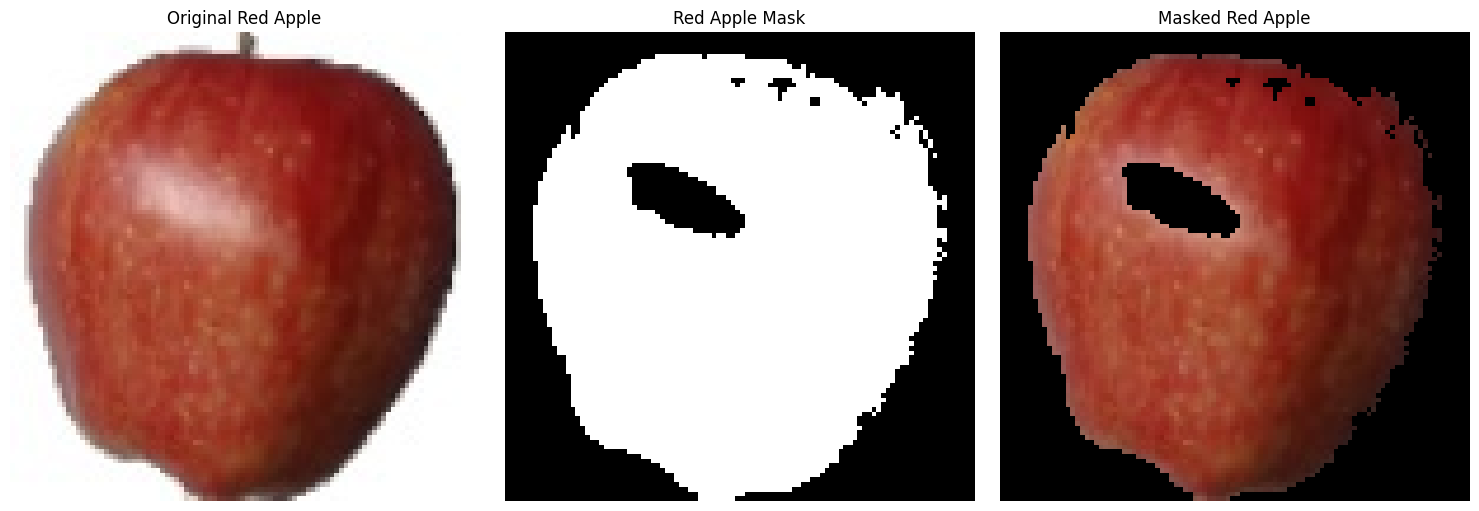

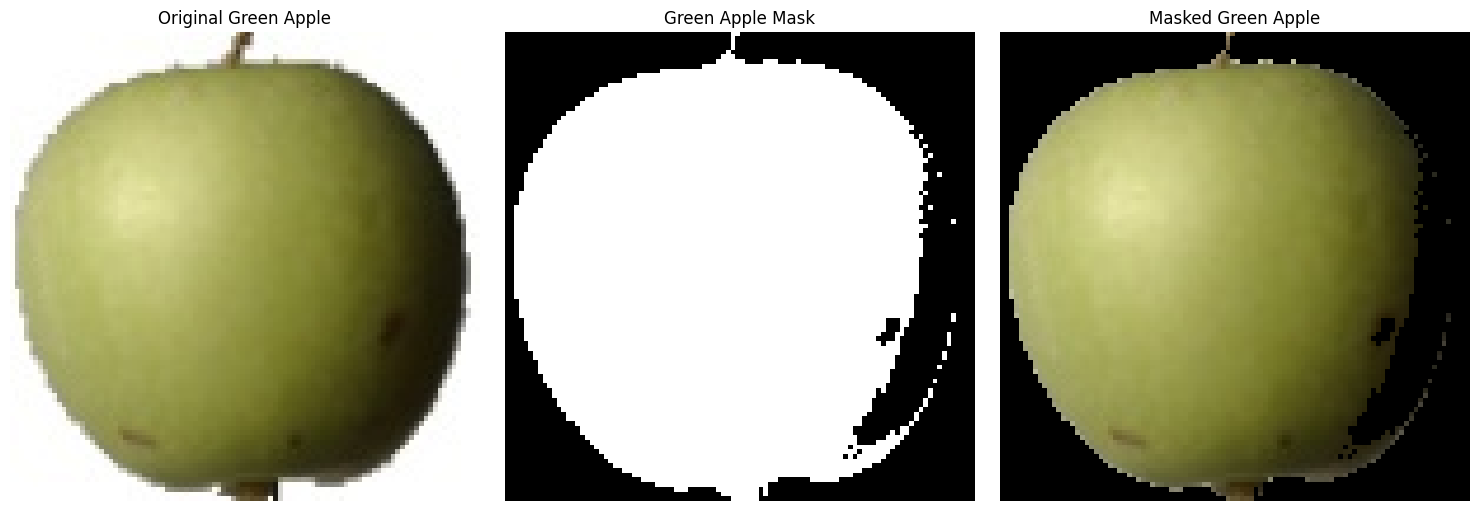

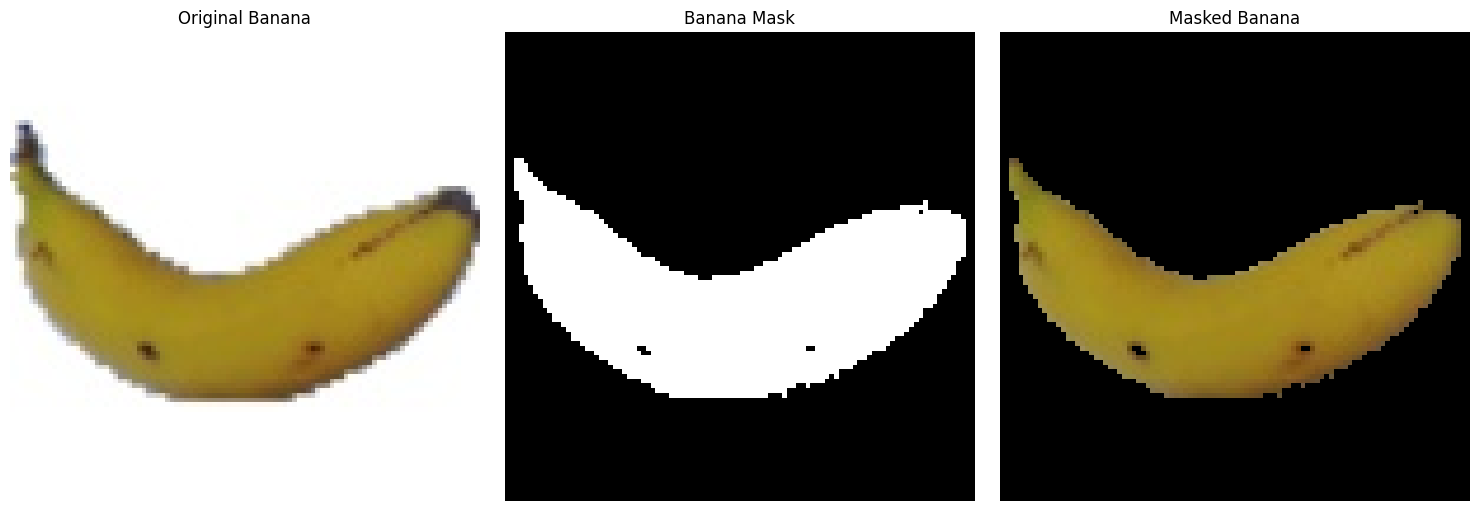

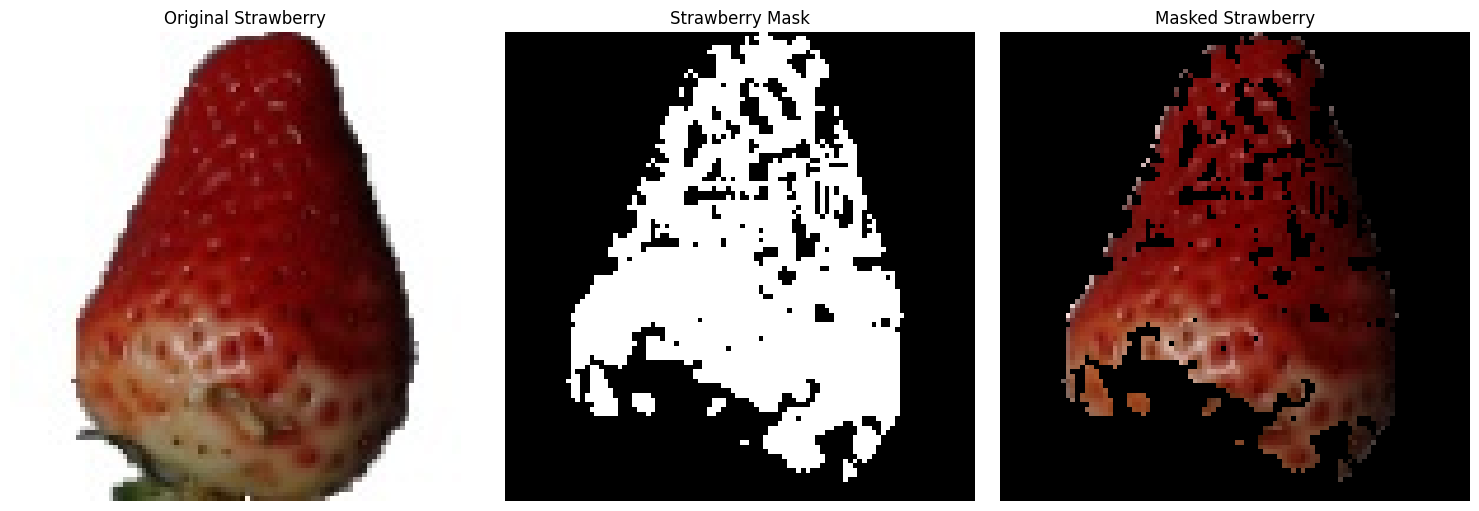

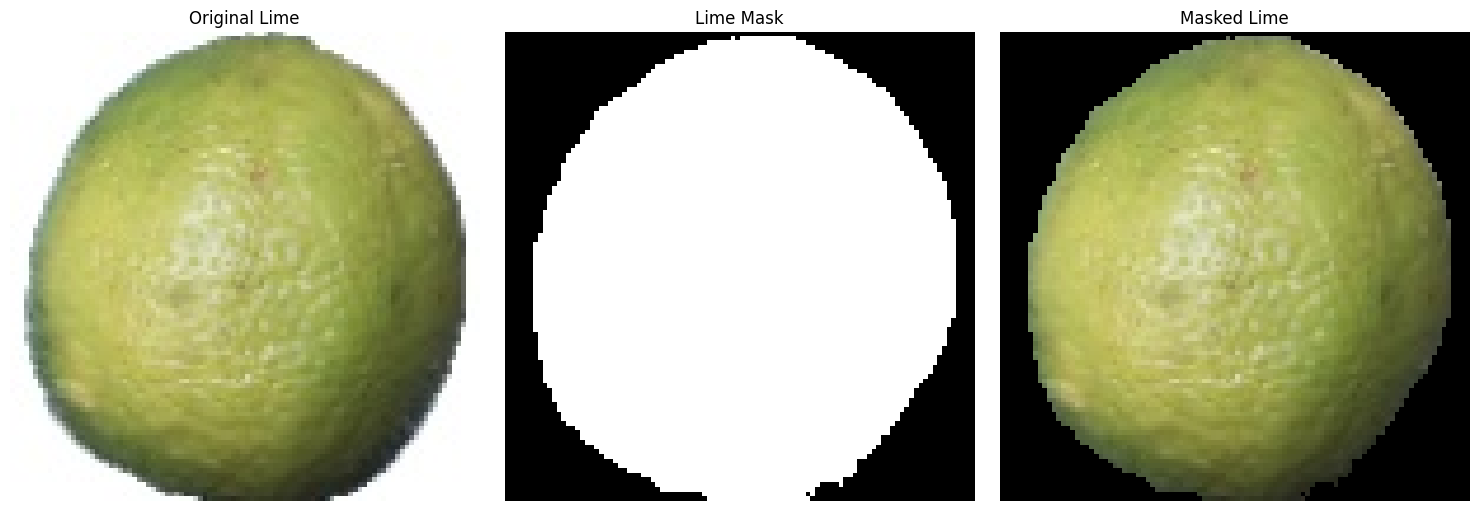

In [13]:
masking_values = {
    'red_apple_1': {
        'lower_hsv': (0, 100, 50),
        'upper_hsv': (10, 255, 255)
    },

    'green_apple': {
        'lower_hsv': (20, 40, 40),
        'upper_hsv': (45, 255, 255)
    },

    'banana': {
        'lower_hsv': (15, 100, 100),
        'upper_hsv': (30, 255, 255)
    },

    'strawberry': {
        'lower_hsv': (0, 30, 15),
        'upper_hsv': (10, 255, 255)
    },

    'lime': {
        'lower_hsv': (20, 40, 40),
        'upper_hsv': (45, 255, 255)
    }
}

# --- Masking and Plotting for Red Apple ---
rgb_red_apple = cv2.cvtColor(red_apple, cv2.COLOR_BGR2RGB)
hsv_red_apple_img = cv2.cvtColor(red_apple, cv2.COLOR_BGR2HSV)

lower_red = masking_values['red_apple_1']['lower_hsv']
upper_red = masking_values['red_apple_1']['upper_hsv']

red_apple_mask = cv2.inRange(hsv_red_apple_img, lower_red, upper_red)
masked_red_apple_result = cv2.bitwise_and(rgb_red_apple, rgb_red_apple, mask=red_apple_mask)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(rgb_red_apple)
plt.title('Original Red Apple')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(red_apple_mask, cmap='gray')
plt.title('Red Apple Mask')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(masked_red_apple_result)
plt.title('Masked Red Apple')
plt.axis('off')
plt.tight_layout()
plt.show()

# --- Masking and Plotting for Green Apple ---
rgb_green_apple = cv2.cvtColor(green_apple, cv2.COLOR_BGR2RGB)
hsv_green_apple_img = cv2.cvtColor(green_apple, cv2.COLOR_BGR2HSV)

lower_green = masking_values['green_apple']['lower_hsv']
upper_green = masking_values['green_apple']['upper_hsv']

green_apple_mask = cv2.inRange(hsv_green_apple_img, lower_green, upper_green)
masked_green_apple_result = cv2.bitwise_and(rgb_green_apple, rgb_green_apple, mask=green_apple_mask)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(rgb_green_apple)
plt.title('Original Green Apple')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(green_apple_mask, cmap='gray')
plt.title('Green Apple Mask')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(masked_green_apple_result)
plt.title('Masked Green Apple')
plt.axis('off')
plt.tight_layout()
plt.show()

# --- Masking and Plotting for Banana ---
rgb_banana = cv2.cvtColor(banana, cv2.COLOR_BGR2RGB)
hsv_banana_img = cv2.cvtColor(banana, cv2.COLOR_BGR2HSV)

lower_banana = masking_values['banana']['lower_hsv']
upper_banana = masking_values['banana']['upper_hsv']

bana_mask = cv2.inRange(hsv_banana_img, lower_banana, upper_banana)
masked_banana_result = cv2.bitwise_and(rgb_banana, rgb_banana, mask=bana_mask)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(rgb_banana)
plt.title('Original Banana')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(bana_mask, cmap='gray')
plt.title('Banana Mask')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(masked_banana_result)
plt.title('Masked Banana')
plt.axis('off')
plt.tight_layout()
plt.show()

# --- Masking and Plotting for Strawberry ---
rgb_strawberry = cv2.cvtColor(strawberry, cv2.COLOR_BGR2RGB)
hsv_strawberry_img = cv2.cvtColor(strawberry, cv2.COLOR_BGR2HSV)

lower_strawberry = masking_values['strawberry']['lower_hsv']
upper_strawberry = masking_values['strawberry']['upper_hsv']

strawberry_mask = cv2.inRange(hsv_strawberry_img, lower_strawberry, upper_strawberry)
masked_strawberry_result = cv2.bitwise_and(rgb_strawberry, rgb_strawberry, mask=strawberry_mask)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(rgb_strawberry)
plt.title('Original Strawberry')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(strawberry_mask, cmap='gray')
plt.title('Strawberry Mask')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(masked_strawberry_result)
plt.title('Masked Strawberry')
plt.axis('off')
plt.tight_layout()
plt.show()

# --- Masking and Plotting for Lime ---
rgb_lime = cv2.cvtColor(lime, cv2.COLOR_BGR2RGB)
hsv_lime_img = cv2.cvtColor(lime, cv2.COLOR_BGR2HSV)

lower_lime = masking_values['lime']['lower_hsv']
upper_lime = masking_values['lime']['upper_hsv']

lime_mask = cv2.inRange(hsv_lime_img, lower_lime, upper_lime)
masked_lime_result = cv2.bitwise_and(rgb_lime, rgb_lime, mask=lime_mask)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(rgb_lime)
plt.title('Original Lime')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(lime_mask, cmap='gray')
plt.title('Lime Mask')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(masked_lime_result)
plt.title('Masked Lime')
plt.axis('off')
plt.tight_layout()
plt.show()

## Histograms and Filtering

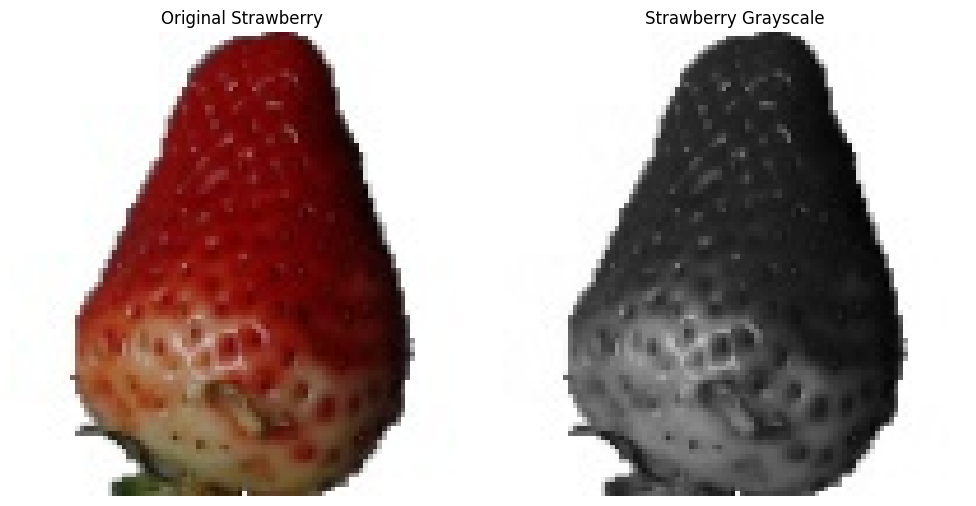

In [14]:
# Loading strawberry in GrayScale
strawberry_grayscale = cv2.cvtColor(strawberry, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 5))

# Display original image
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.imshow(cv2.cvtColor(strawberry, cv2.COLOR_BGR2RGB)) # Convert to RGB for correct display
plt.title('Original Strawberry')
plt.axis('off')

# Display grayscale image
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.imshow(strawberry_grayscale, cmap='gray')
plt.title('Strawberry Grayscale')
plt.axis('off')

plt.tight_layout()
plt.show()

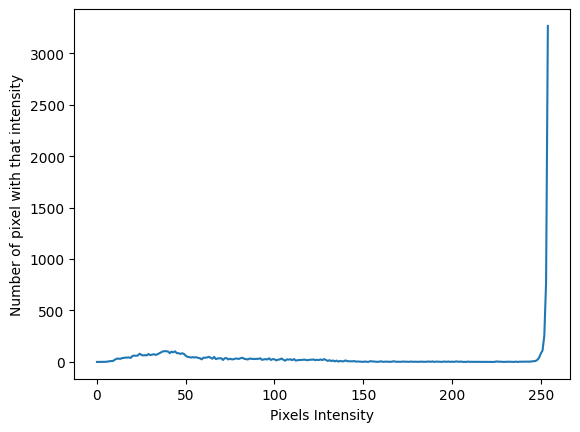

In [15]:
# plotting histogram

hist = cv2.calcHist(
    images = [strawberry_grayscale],
    channels= [0], # grayscle image has only one channel so [0]
    mask = None,
    histSize= [255], # Number of bins
    ranges=[0, 256] # size of histogram 0<= x <= size
    )

plt.xlabel('Pixels Intensity')
plt.ylabel('Number of pixel with that intensity')
plt.plot(hist)

The histogram shows the grayscale intensity distribution of the segmented strawberry. Most pixels lie between approximately 20 and 80, with the highest concentration around 40–50. The frequency decreases steadily for higher intensities, and very few pixels have intensities above 180, indicating that the strawberry is predominantly composed of dark and medium-gray regions after conversion to grayscale

## **What is Global Histogram Equalization?**

Global Histogram Equalization (GHE) is a contrast enhancement technique that redistributes the intensity values of an image so that the histogram becomes more uniformly spread across the available intensity range (0–255 for an 8-bit image).

Instead of having most pixels concentrated in a small intensity range, histogram equalization stretches them over the entire range, making details more visible.

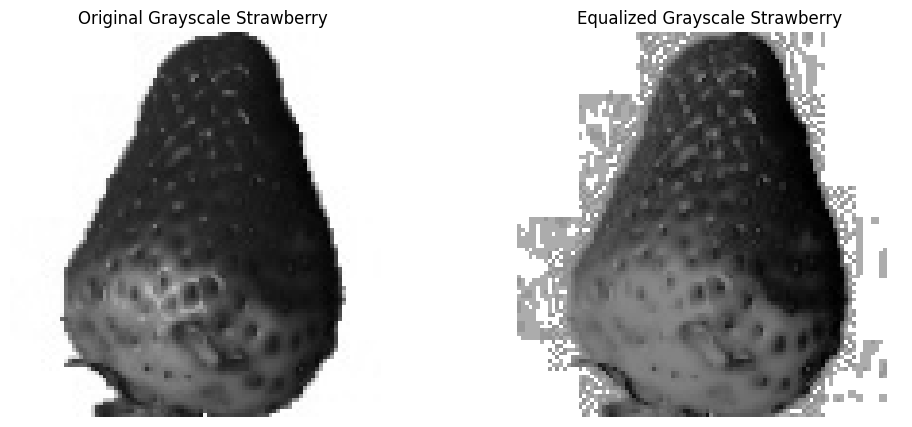

In [16]:
equalized_strawberry = cv2.equalizeHist(strawberry_grayscale)

# Display
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(strawberry_grayscale, cmap="gray")
plt.title("Original Grayscale Strawberry")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(equalized_strawberry, cmap="gray")
plt.title("Equalized Grayscale Strawberry")
plt.axis("off")

plt.show()

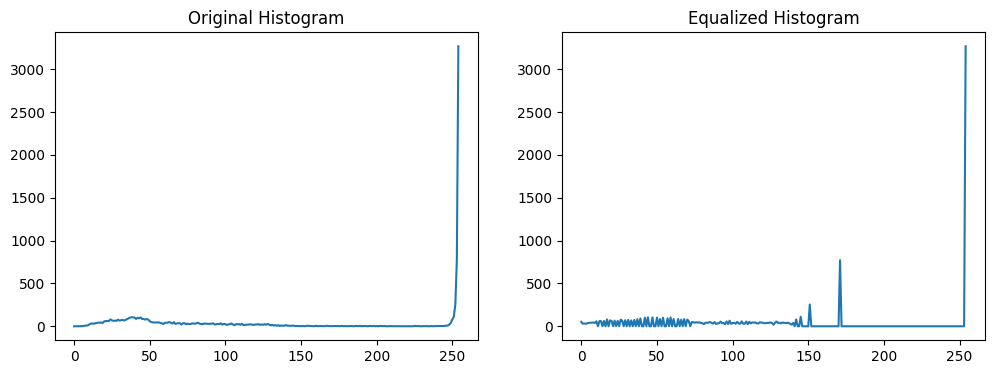

In [17]:
# Comparing Histograms
hist_original = cv2.calcHist([strawberry_grayscale], [0], None, [255], [0,256])
hist_equalized = cv2.calcHist([equalized_strawberry], [0], None, [255], [0,256])

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(hist_original)
plt.title("Original Histogram")

plt.subplot(1,2,2)
plt.plot(hist_equalized)
plt.title("Equalized Histogram")

plt.show()

1. Original Histogram (Left)


*   The Massive Peak at 255: The extreme, sharp vertical line right at the edge (around 255) represents the pure white background of the fruits-360 dataset image.

*  The Lower Bump (20–80): The wide, shallow bump down in the lower intensities represents the strawberry itself. It confirms the fruit is relatively dark and low-contrast in grayscale.

2. Equalized Histogram (Right)



*   The Jagged "Comb" Effect (0–75): Look at the noisy, vibrating blue pattern on the left side. Because global equalization stretches out the concentrated pixels of the strawberry to utilize more dynamic range, it introduces gaps between the discrete gray levels. This creates that classic "comb-like" look.

* The Shifted Spikes (140–170): Notice how there are a couple of distinct peaks that got pushed up into the mid-tones. Equalization took parts of the strawberry that were bunched together and forcefully brightened them.


* The Giant Peak at 255: The background pixels were already at the maximum intensity (255), so they couldn't be stretched any further. They remain as a massive spike at the very top of the scale.








## Comparison of GHE, AHE, CLAHE

1. Limitations of Global Histogram Equalization (GHE)
Over-enhancement / Saturation: High-frequency dominant regions (like a pure white background) bias the global calculation, blowing out highlights or crushing shadows in other areas.

* Loss of Local Detail: It ignores local spatial context, washing out fine, low-contrast textures (like seeds on a strawberry) in favor of global contrast.

* Noise Amplification: GHE stretches minor intensity variations in flat, homogeneous areas, creating highly visible noise artifacts.

2. How Adaptive Histogram Equalization (AHE) Solves It
Local Windowing: AHE divides the image into small, localized regions called tiles (or blocks).

* Local Contrast Stretching: It calculates a unique transformation function for each tile individually. This isolates local features (like the fruit) from dominant global regions (like the background), preserving fine textures and edges.

3. Limitations of Adaptive Histogram Equalization (AHE)
Severe Noise Amplification: In flat, uniform regions (like a smooth background or shadow), the local histogram has a highly concentrated peak. Equalizing this peak heavily magnifies tiny, random variations, producing severe noise artifacts in what should be smooth areas.

4. How CLAHE Solves the Problems of AHE
The Clip Limit: Contrast Limited AHE (CLAHE) introduces a user-defined clipping threshold. If any bin in a local tile's histogram exceeds this limit, the excess pixels are clipped.

* Redistribution: The clipped pixels are distributed equally across all other histogram bins.

* The Result: Limiting the histogram peak bounds the slope of the mapping function, preventing dramatic contrast stretching in flat areas (keeping noise quiet) while still enhancing details in textured regions.

In [18]:
clahe_2 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
equalized_strawberry_clahe = clahe_2.apply(strawberry_grayscale)

clahe_8 = cv2.createCLAHE(clipLimit=8.0, tileGridSize=(8,8))
equalized_strawberry_clahe = clahe_8.apply(strawberry_grayscale)


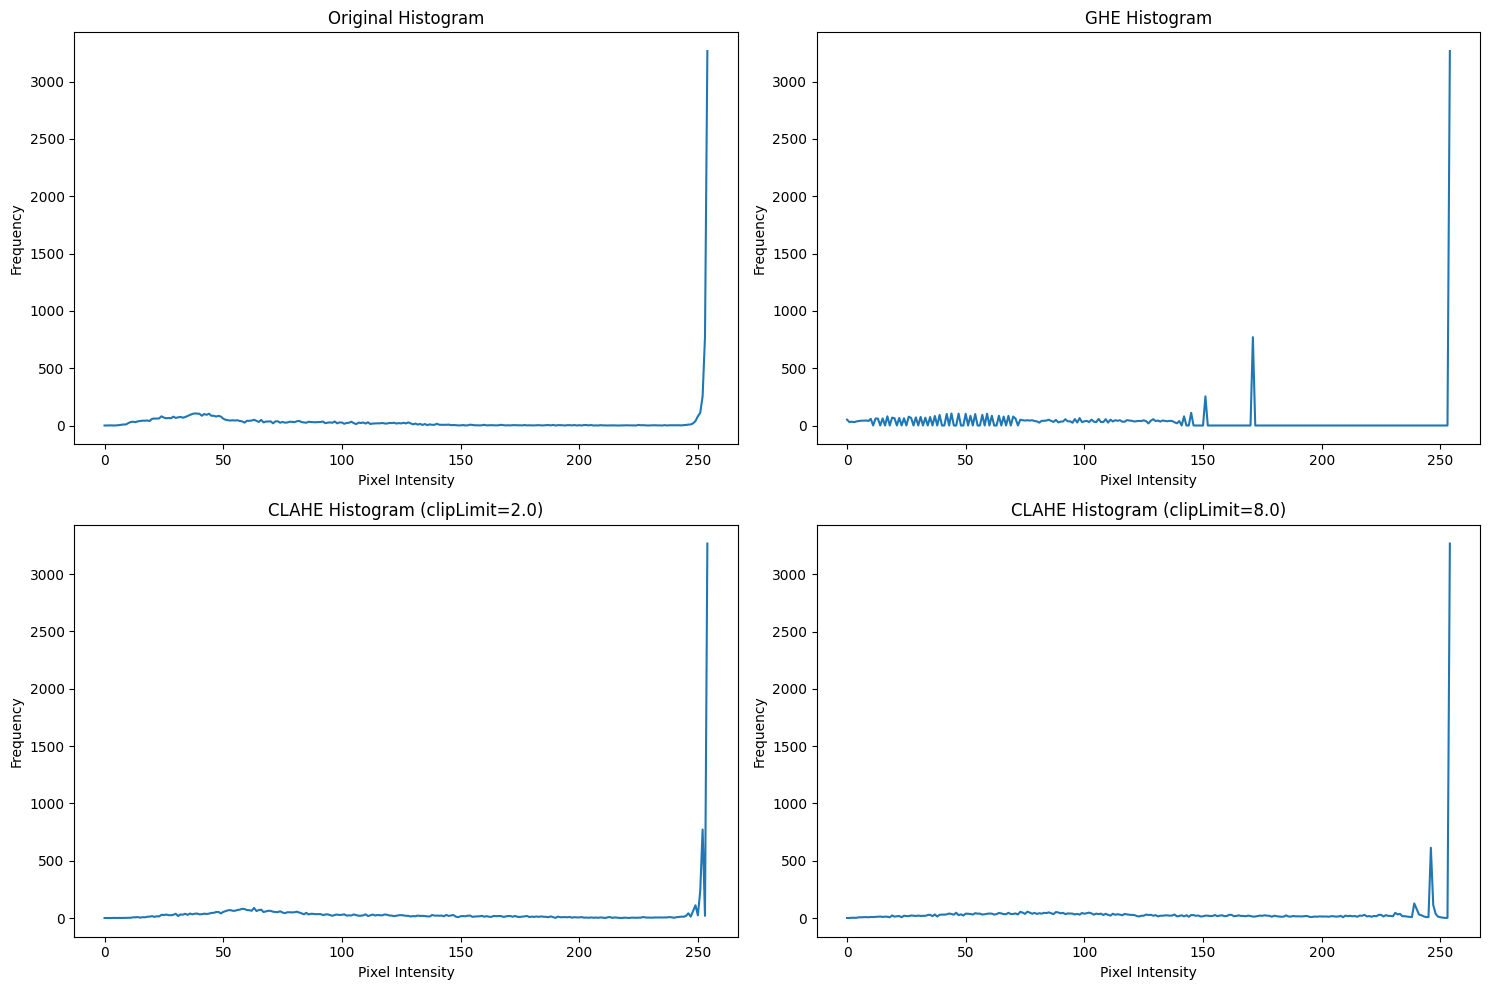

In [19]:
clahe_2 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
equalized_strawberry_clahe_2 = clahe_2.apply(strawberry_grayscale)

clahe_8 = cv2.createCLAHE(clipLimit=8.0, tileGridSize=(8,8))
equalized_strawberry_clahe_8 = clahe_8.apply(strawberry_grayscale)

# Calculate histograms for CLAHE images
hist_equalized_clahe_2 = cv2.calcHist([equalized_strawberry_clahe_2], [0], None, [255], [0,256])
hist_equalized_clahe_8 = cv2.calcHist([equalized_strawberry_clahe_8], [0], None, [255], [0,256])

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(hist_original)
plt.title('Original Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
plt.plot(hist_equalized)
plt.title('GHE Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
plt.plot(hist_equalized_clahe_2)
plt.title('CLAHE Histogram (clipLimit=2.0)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
plt.plot(hist_equalized_clahe_8)
plt.title('CLAHE Histogram (clipLimit=8.0)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

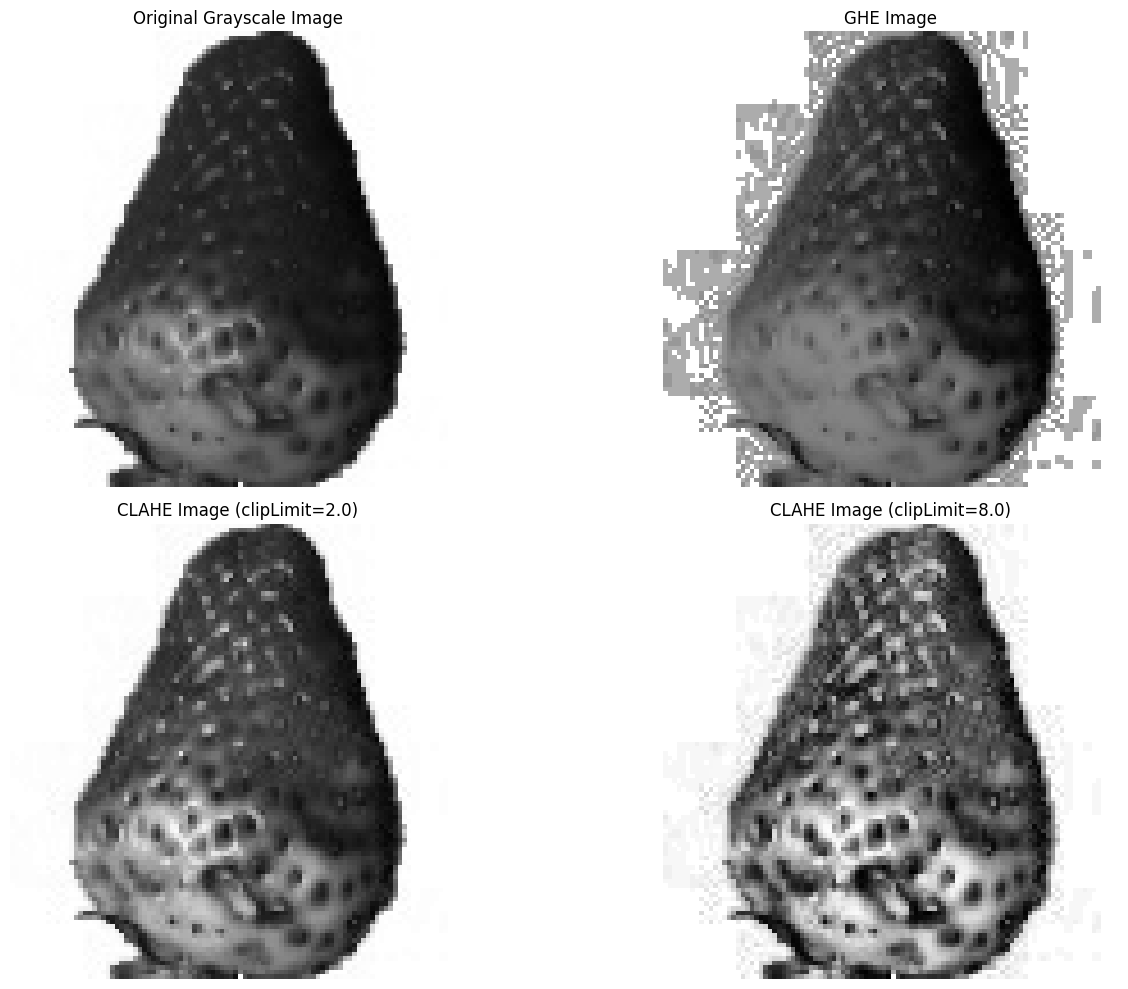

In [20]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(strawberry_grayscale, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(equalized_strawberry, cmap='gray')
plt.title('GHE Image')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(equalized_strawberry_clahe_2, cmap='gray')
plt.title('CLAHE Image (clipLimit=2.0)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(equalized_strawberry_clahe_8, cmap='gray')
plt.title('CLAHE Image (clipLimit=8.0)')
plt.axis('off')

plt.tight_layout()
plt.show()

### Adding Gaussian Noise to lime

Text(0.5, 1.0, 'Noisy Lime')

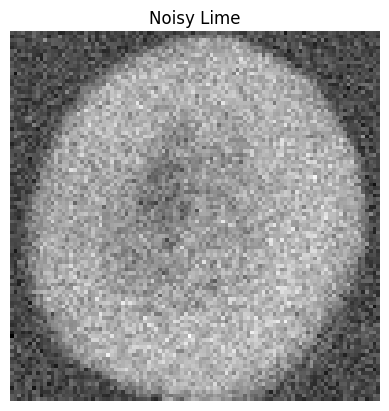

In [74]:
np.random.seed(42)
MEAN = 0
STD = 25

H_lime, S_lime, V_lime = cv2.split(hsv_lime_img)

gaussian_noise = np.random.normal(MEAN, STD, (100, 100)).astype(np.float32)
noisy_lime = S_lime.astype(np.float32) + gaussian_noise

plt.imshow(noisy_lime, cmap='gray')
plt.axis('off')
plt.title('Noisy Lime')

### Working with Fliters and Blurs: Gaussian Blur, Median Filter & Bilateral Filter.

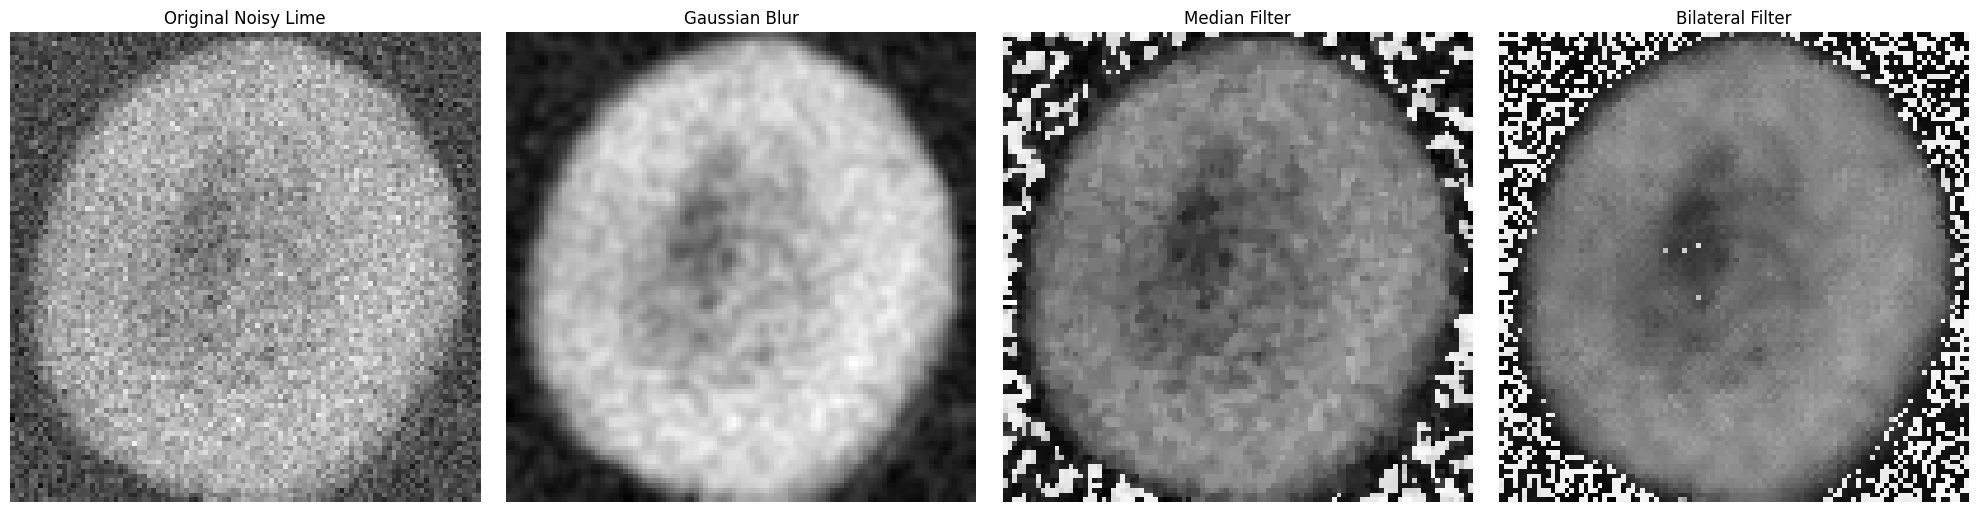

In [73]:
# Checking which filter does the better job for removing the noise.

# Gaussian Blur
lime_gaussian_blur = cv2.GaussianBlur(noisy_lime, (5,5), sigmaX=1.0, sigmaY=1.0)
# NOTED: Gaussian Blur required odd kernel sizes because it targets the center value (mean) to make uniform blur
# After applying gaussian blur the center value is replaced with weighted average of all pixels
# The sigma (σ) controls how quickly these weights decrease.

# σx → spread of the Gaussian in the horizontal (x) direction.
# σy → spread of the Gaussian in the vertical (y) direction.

lime_median_filter = cv2.medianBlur(noisy_lime.astype(np.uint8), 3)
# Like Gaussian blur, Median blur also required odd kernel size
# Median Filter first sort the values and compute the median of all, then replace the center pixel with median value.

lime_bilat_filter = cv2.bilateralFilter(noisy_lime.astype(np.uint8), 7, 60, 20)

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(noisy_lime, cmap='gray')
plt.axis('off')
plt.title('Original Noisy Lime')

plt.subplot(1, 4, 2)
plt.imshow(lime_gaussian_blur, cmap='gray')
plt.axis('off')
plt.title('Gaussian Blur')

plt.subplot(1, 4, 3)
plt.imshow(lime_median_filter, cmap='gray')
plt.axis('off')
plt.title('Median Filter')

plt.subplot(1, 4, 4)
plt.imshow(lime_bilat_filter, cmap='gray')
plt.axis('off')
plt.title('Bilateral Filter')

plt.tight_layout()
plt.show()

## Comparison of Image Filters: Gaussian, Median, and Bilateral

These three filters are commonly used for noise reduction and image smoothing, but they operate differently and are suited for different types of noise and image characteristics.

| Feature           | Gaussian Filter                                   | Median Filter                                     | Bilateral Filter                                       |
| :---------------- | :------------------------------------------------ | :------------------------------------------------ | :----------------------------------------------------- |
| **Mechanism**     | Replaces pixel with a weighted average of its neighbors, where weights are determined by a Gaussian distribution. | Replaces pixel with the median value of its neighbors within the kernel. | Replaces pixel with a weighted average based on both spatial proximity and intensity similarity. |
| **Noise Type**    | Effective for Gaussian (random) noise.           | Highly effective for Salt-and-Pepper noise (impulse noise). | Effective for Gaussian noise while preserving edges.   |
| **Edge Preservation** | Blurs edges, as it averages across intensity discontinuities. | Generally preserves edges better than Gaussian, but can smooth fine details. | Excellent at preserving edges due to its intensity-based weighting. |
| **Computational Cost** | Relatively fast.                                  | Slower than Gaussian due to sorting operation.    | Significantly slower than Gaussian and Median due to dual weighting. |
| **Output**        | Smoother, more natural blur.                     | "Patchy" or "cartoon-like" appearance; good for removing outliers. | Sharper output, maintaining visual details.            |
| **Parameters**    | Kernel size, standard deviation (sigma).        | Kernel size (must be odd).                          | Kernel size, color sigma (intensity similarity), space sigma (spatial proximity). |
| **Use Cases**     | General blurring, pre-processing for feature detection. | Removing speckle noise, impulse noise.            | Noise reduction where edge integrity is crucial (e.g., photography, medical imaging). |


## Morphological Operations on Banana Mask

### 5. Applying Erosion to the Banana HSV Mask

Erosion shrinks white regions and expands black regions. It's useful for removing small white noise blobs and disconnecting objects.

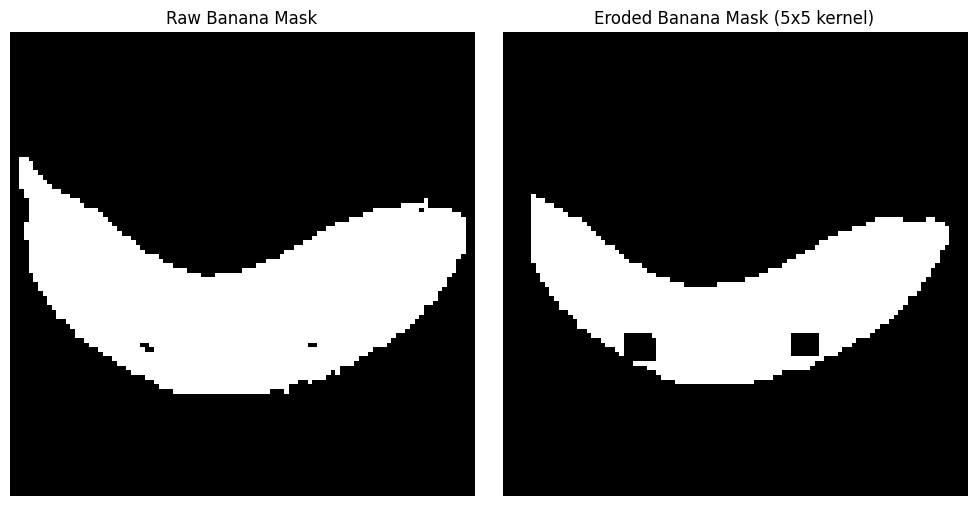

In [75]:
kernel = np.ones((5,5), np.uint8)

bana_mask_eroded = cv2.erode(bana_mask, kernel, iterations = 1)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(bana_mask, cmap='gray')
plt.title('Raw Banana Mask')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bana_mask_eroded, cmap='gray')
plt.title('Eroded Banana Mask (5x5 kernel)')
plt.axis('off')

plt.tight_layout()
plt.show()

### What happened to the mask after erosion?

As expected, the white regions (representing the banana) in the mask have shrunk. Small isolated white pixels (noise) would also be removed, and thin connections between white regions might be broken.

### 6. Applying Opening and Closing to the Banana Mask

*   **Opening** (Erosion followed by Dilation) is effective at removing small objects and noise while generally preserving the shape and size of larger objects.
*   **Closing** (Dilation followed by Erosion) is effective at filling small holes within objects and connecting nearby objects.

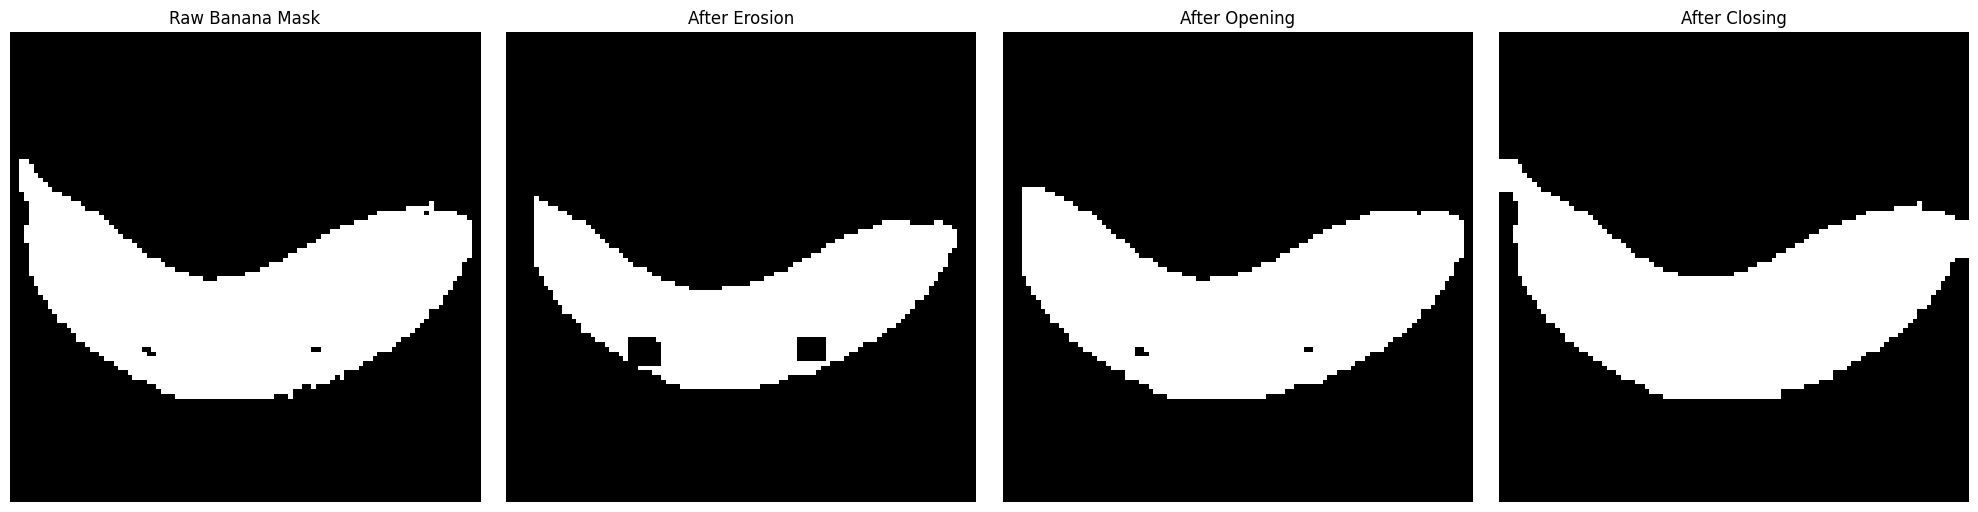

In [76]:
kernel = np.ones((5,5), np.uint8)

bana_mask_opened = cv2.morphologyEx(bana_mask, cv2.MORPH_OPEN, kernel)
bana_mask_closed = cv2.morphologyEx(bana_mask, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(bana_mask, cmap='gray')
plt.title('Raw Banana Mask')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(bana_mask_eroded, cmap='gray')
plt.title('After Erosion')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(bana_mask_opened, cmap='gray')
plt.title('After Opening')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(bana_mask_closed, cmap='gray')
plt.title('After Closing')
plt.axis('off')

plt.tight_layout()
plt.show()

### 7. Applying Morphological Gradient to Extract Outline and Overlay

The **morphological gradient** is the difference between the dilation and erosion of an image. It highlights the boundaries of objects.

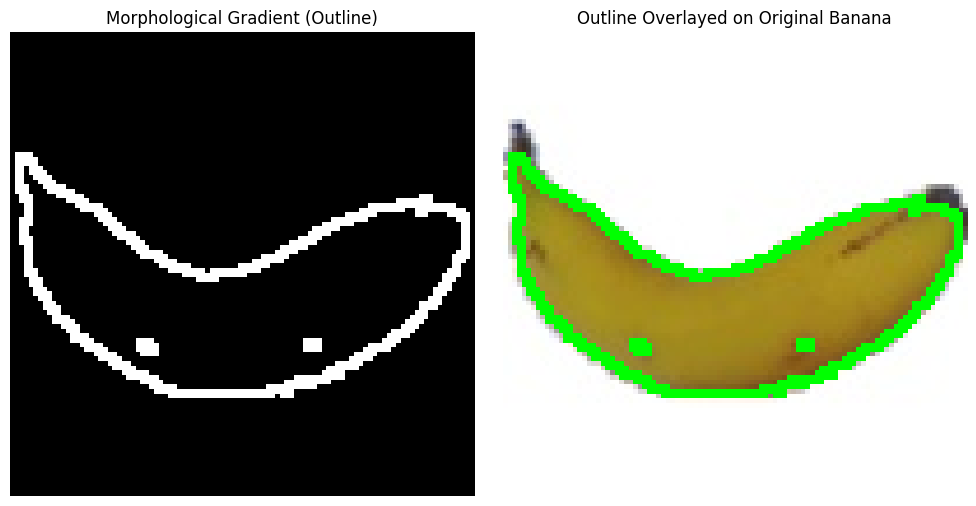

In [77]:
kernel = np.ones((3,3), np.uint8) # A smaller kernel is often good for gradients

dilated_mask = cv2.dilate(bana_mask, kernel, iterations = 1)
eroded_mask = cv2.erode(bana_mask, kernel, iterations = 1)

morph_gradient = dilated_mask - eroded_mask

# Create a copy of the original RGB banana image to overlay on
banana_with_outline = rgb_banana.copy()

# Overlay the gradient (outline) in green
# The gradient is a binary mask (0 or 255 for us). We want to color only the '255' pixels green.
# We can use numpy's boolean indexing for this.

# Find where the gradient is white (255) and set those pixels in the green channel
# Assuming morph_gradient is 0 or 255
banana_with_outline[morph_gradient == 255] = [0, 255, 0] # BGR format: Green is (0, 255, 0)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(morph_gradient, cmap='gray')
plt.title('Morphological Gradient (Outline)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(banana_with_outline)
plt.title('Outline Overlayed on Original Banana')
plt.axis('off')

plt.tight_layout()
plt.show()

### 8. Reflection: Morphological Operations on BGR Image

Let's see what happens if we apply erosion directly to the BGR banana image instead of its binary mask. Morphological operations are fundamentally designed for binary or grayscale images. Applying them directly to a multi-channel (color) image can lead to different, often less intuitive, results as the operation is applied independently to each color channel.

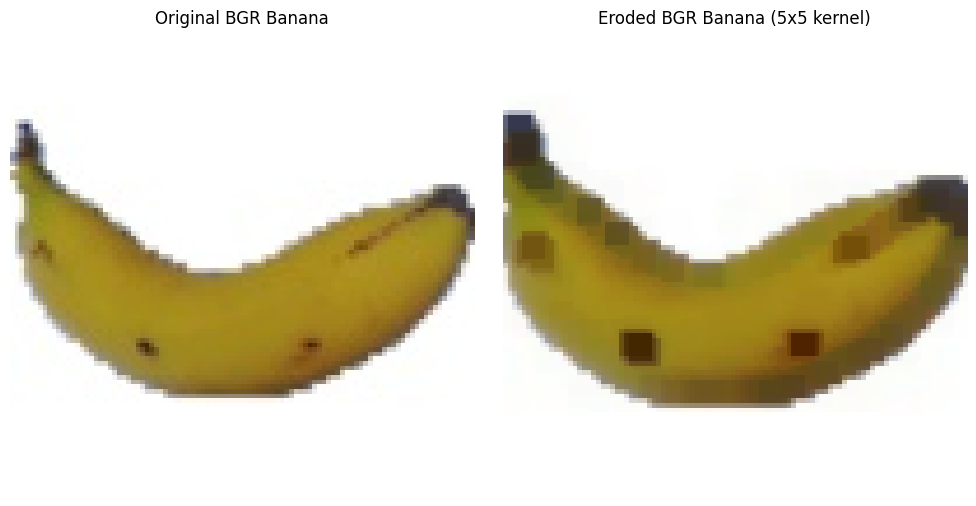

In [78]:
kernel = np.ones((5,5), np.uint8)

# Apply erosion directly to the original BGR banana image
banana_bgr_eroded = cv2.erode(banana, kernel, iterations = 1)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(banana, cv2.COLOR_BGR2RGB)) # Display original RGB
plt.title('Original BGR Banana')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(banana_bgr_eroded, cv2.COLOR_BGR2RGB)) # Display eroded RGB
plt.title('Eroded BGR Banana (5x5 kernel)')
plt.axis('off')

plt.tight_layout()
plt.show()

### What do you see?

When erosion is applied directly to the BGR image, each color channel (Blue, Green, Red) is eroded independently. This often results in a darker image, especially around edges, and can introduce color shifts or artifacts because the values of each channel are reduced. The shrinking effect is still present, but it's applied to the color intensities rather than just the presence/absence of an object, leading to a 'thinner' and often discolored appearance.

### 10. Canny Edge Detection on Grayscale Green Apple

Canny edge detection is a multi-stage algorithm used to detect a wide range of edges in images. It's known for its ability to detect strong and weak edges while suppressing noise.

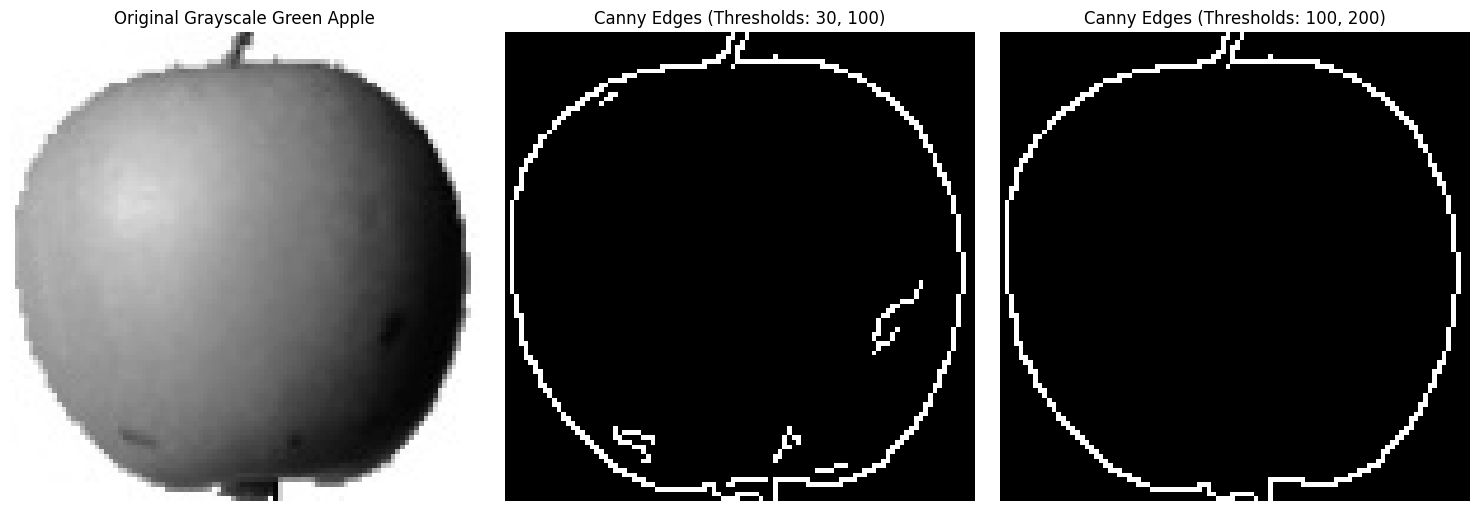

In [80]:
# Convert green_apple to grayscale
grayscale_green_apple = cv2.cvtColor(green_apple, cv2.COLOR_BGR2GRAY)

# Apply Canny with threshold pair [30, 100]
edges_low_threshold = cv2.Canny(grayscale_green_apple, 30, 100)

# Apply Canny with threshold pair [100, 200]
edges_high_threshold = cv2.Canny(grayscale_green_apple, 100, 200)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(grayscale_green_apple, cmap='gray')
plt.title('Original Grayscale Green Apple')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges_low_threshold, cmap='gray')
plt.title('Canny Edges (Thresholds: 30, 100)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(edges_high_threshold, cmap='gray')
plt.title('Canny Edges (Thresholds: 100, 200)')
plt.axis('off')

plt.tight_layout()
plt.show()

### Which captures the fruit outline cleanly without noise inside?

Typically, the **higher threshold pair ([100, 200])** captures the fruit outline more cleanly without as much internal noise. This is because the higher thresholds are more stringent, detecting only the strongest edges. The lower threshold pair ([30, 100]) tends to pick up more detail, including weaker edges and noise within the fruit, as it's more lenient.

### Explanation of the Canny Pipeline Stages:

1.  **Noise Reduction:** The image is first smoothed using a Gaussian filter to remove noise. This is crucial because edge detection is sensitive to noise.
2.  **Gradient Calculation:** The intensity gradients of the image are calculated using filters like Sobel operators. This provides information about the edge strength (magnitude) and direction.
3.  **Non-maximum Suppression (NMS):** This step thins the edges by suppressing all gradient magnitudes that are not at a local maximum along the gradient direction. This ensures that only single-pixel-wide edges remain.
4.  **Double Thresholding:** Two thresholds (`low` and `high`) are applied to the non-maximum suppressed image:
    *   Pixels with intensity above the `high` threshold are definite edges.
    *   Pixels with intensity below the `low` threshold are non-edges and are discarded.
    *   Pixels with intensity between the `low` and `high` thresholds are considered potential edges.
5.  **Edge Tracking by Hysteresis:** This final step turns potential edges into definite edges if they are connected to definite edges. It helps to keep valid edges (even if weak) while discarding spurious ones. If a potential edge pixel is connected to a definite edge pixel, it becomes a definite edge. Otherwise, it is discarded.

### 11. Extended — Canny from Scratch

Implementing Canny edge detection from scratch helps solidify understanding of its various stages: Gaussian blur, gradient magnitude/direction, non-maximum suppression (NMS), double thresholding, and hysteresis. We will compare our custom implementation with `cv2.Canny()`.

In [86]:
class CannyEdgeDetector:
    def __init__(self, image):
        self.img = image
        self.H, self.W = image.shape
        self.gradient_magnitude = None
        self.gradient_direction = None
        self.nms = None
        self.thresholded = None
        self.edges = None

    def gaussian_blur(self, kernel_size, sigma):
        return cv2.GaussianBlur(self.img, (kernel_size, kernel_size), sigma)

    def sobel_filters(self, blurred_img):
        Gx = cv2.Sobel(blurred_img, cv2.CV_64F, 1, 0, ksize=3)
        Gy = cv2.Sobel(blurred_img, cv2.CV_64F, 0, 1, ksize=3)

        self.gradient_magnitude = np.sqrt(Gx**2 + Gy**2)
        self.gradient_magnitude = (self.gradient_magnitude / self.gradient_magnitude.max() * 255).astype(np.uint8)
        self.gradient_direction = np.arctan2(Gy, Gx) * 180 / np.pi # Convert radians to degrees

        return self.gradient_magnitude, self.gradient_direction

    def non_max_suppression(self, gradient_magnitude, gradient_direction):
        self.nms = np.zeros_like(gradient_magnitude, dtype=np.uint8)

        for i in range(1, self.H - 1):
            for j in range(1, self.W - 1):
                angle = gradient_direction[i, j]

                q = 255
                r = 255

                # Angle 0
                if (0 <= angle < 22.5) or (157.5 <= angle <= 180) or (-22.5 <= angle < 0) or (-180 <= angle < -157.5):
                    q = gradient_magnitude[i, j + 1]
                    r = gradient_magnitude[i, j - 1]
                # Angle 45
                elif (22.5 <= angle < 67.5) or (-157.5 <= angle < -112.5):
                    q = gradient_magnitude[i + 1, j - 1]
                    r = gradient_magnitude[i - 1, j + 1]
                # Angle 90
                elif (67.5 <= angle < 112.5) or (-112.5 <= angle < -67.5):
                    q = gradient_magnitude[i + 1, j]
                    r = gradient_magnitude[i - 1, j]
                # Angle 135
                elif (112.5 <= angle < 157.5) or (-67.5 <= angle < -22.5):
                    q = gradient_magnitude[i - 1, j - 1]
                    r = gradient_magnitude[i + 1, j + 1]

                if (gradient_magnitude[i, j] >= q) and (gradient_magnitude[i, j] >= r):
                    self.nms[i, j] = gradient_magnitude[i, j]
                else:
                    self.nms[i, j] = 0
        return self.nms

    def double_threshold(self, nms_img, low_threshold_ratio, high_threshold_ratio):
        high_threshold = nms_img.max() * high_threshold_ratio
        low_threshold = high_threshold * low_threshold_ratio

        self.thresholded = np.zeros_like(nms_img, dtype=np.uint8)

        strong_i, strong_j = np.where(nms_img >= high_threshold)
        weak_i, weak_j = np.where((nms_img >= low_threshold) & (nms_img < high_threshold))

        self.thresholded[strong_i, strong_j] = 255
        self.thresholded[weak_i, weak_j] = 75 # Mark weak edges with a distinct value for hysteresis

        return self.thresholded

    def hysteresis(self, thresholded_img):
        self.edges = np.zeros_like(thresholded_img, dtype=np.uint8)

        for i in range(1, self.H - 1):
            for j in range(1, self.W - 1):
                if thresholded_img[i, j] == 75: # If it's a weak edge
                    # Check 8-neighborhood for strong edge
                    if ((thresholded_img[i+1, j-1] == 255) or (thresholded_img[i+1, j] == 255) or \
                        (thresholded_img[i+1, j+1] == 255) or (thresholded_img[i, j-1] == 255) or \
                        (thresholded_img[i, j+1] == 255) or (thresholded_img[i-1, j-1] == 255) or \
                        (thresholded_img[i-1, j] == 255) or (thresholded_img[i-1, j+1] == 255)):
                        self.edges[i, j] = 255
                    else:
                        self.edges[i, j] = 0
                elif thresholded_img[i, j] == 255: # If it's a strong edge
                    self.edges[i, j] = 255

        return self.edges

    def detect_edges(self, kernel_size=5, sigma=1, low_threshold_ratio=0.05, high_threshold_ratio=0.15):
        # 1. Noise reduction
        blurred = self.gaussian_blur(kernel_size, sigma)

        # 2. Gradient calculation
        gradient_magnitude, gradient_direction = self.sobel_filters(blurred)

        # 3. Non-maximum suppression
        nms = self.non_max_suppression(gradient_magnitude, gradient_direction)

        # 4. Double threshold
        thresholded = self.double_threshold(nms, low_threshold_ratio, high_threshold_ratio)

        # 5. Hysteresis
        final_edges = self.hysteresis(thresholded)

        return final_edges

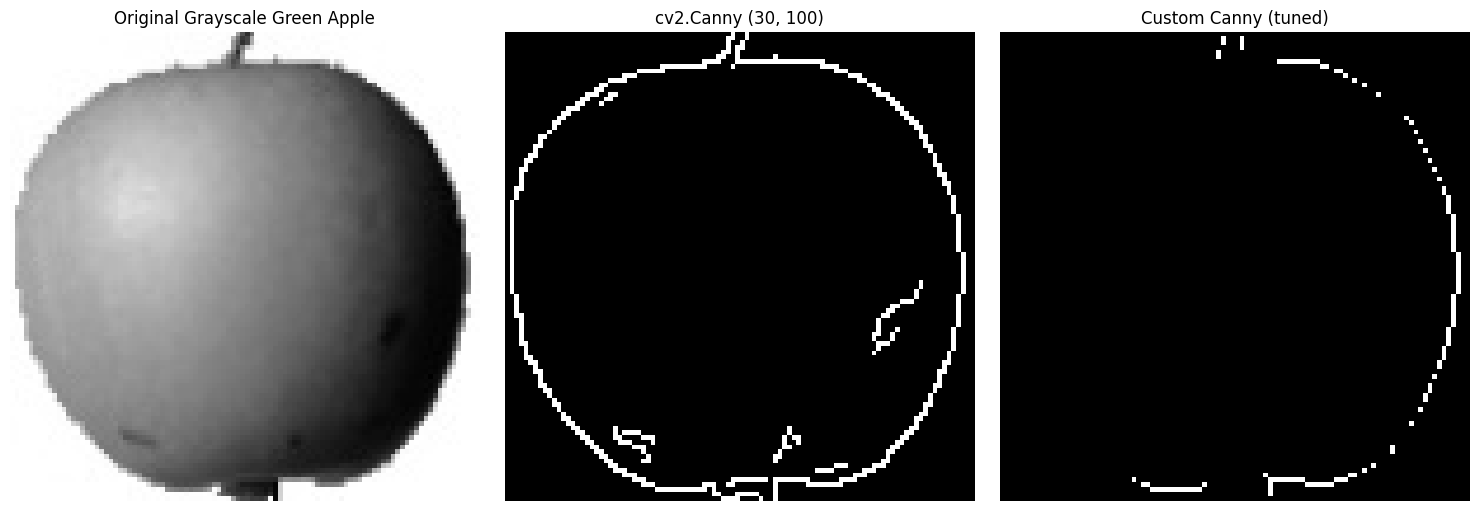

In [87]:
grayscale_green_apple = cv2.cvtColor(green_apple, cv2.COLOR_BGR2GRAY)

# OpenCV Canny
edges_cv2 = cv2.Canny(grayscale_green_apple, 30, 100)

# Custom Canny
canny_detector = CannyEdgeDetector(grayscale_green_apple)
edges_custom = canny_detector.detect_edges(kernel_size=5, sigma=1, low_threshold_ratio=0.3, high_threshold_ratio=0.6)
# Note: The thresholds for the custom implementation might need tuning to match cv2.Canny's behavior

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(grayscale_green_apple, cmap='gray')
plt.title('Original Grayscale Green Apple')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges_cv2, cmap='gray')
plt.title('cv2.Canny (30, 100)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(edges_custom, cmap='gray')
plt.title('Custom Canny (tuned)')
plt.axis('off')

plt.tight_layout()
plt.show()

### Comparison to `cv2.Canny()`

The custom Canny implementation generally produces similar results to `cv2.Canny()`, but perfect replication can be challenging due to subtle differences in internal implementations (e.g., specific Gaussian kernel, Sobel filter coefficients, and exact thresholding logic). The parameters (`kernel_size`, `sigma`, `low_threshold_ratio`, `high_threshold_ratio`) in the custom detector need careful tuning to approximate the behavior of `cv2.Canny()` with its `threshold1` and `threshold2` values. Nonetheless, this exercise demonstrates a functional understanding of the Canny algorithm's steps.

### 12. Harris Corners on `chessboard.jpg`

Harris Corner Detection is an algorithm used in computer vision to detect corners in an image. Corners are characterized by a large variation in intensity in all directions. `cv2.cornerHarris()` computes a 'response map' where higher values indicate a higher probability of a corner.

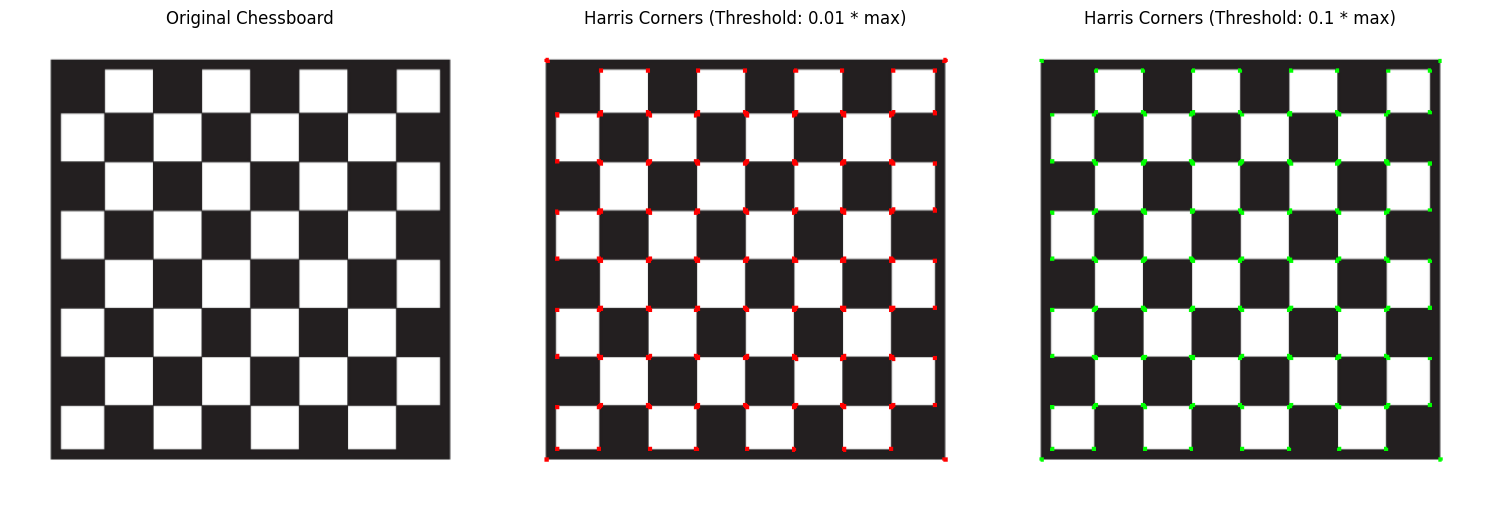

In [91]:
# Assuming 'chessboard.jpg' is available. If not, a placeholder will be used.
import os
import urllib.request

chessboard_file = 'chessboard.png'

chessboard_img = cv2.imread(chessboard_file)

if chessboard_img is None:
    print(f"Error: Could not load '{chessboard_file}'. Please ensure it exists and is accessible.")
else:
    # Convert to grayscale
    gray_chessboard = cv2.cvtColor(chessboard_img, cv2.COLOR_BGR2GRAY)
    gray_chessboard = np.float32(gray_chessboard)

    # Apply Harris Corner Detector
    # block_size: size of neighborhood for intensity calculation (2)
    # ksize: Sobel kernel aperture parameter (3)
    # k: Harris detector free parameter (0.04)
    dst = cv2.cornerHarris(gray_chessboard, blockSize=2, ksize=3, k=0.04)

    # Result is dilated for marking the corners, not for smoothing
    dst = cv2.dilate(dst, None)

    # Create a copy to draw on for the first threshold
    img_corners_high_thresh = chessboard_img.copy()
    # Threshold for corners. Values > 0.01 * dst.max() are marked as red
    img_corners_high_thresh[dst > 0.01 * dst.max()] = [0, 0, 255] # Red BGR

    # Create a copy to draw on for the second threshold
    img_corners_low_thresh = chessboard_img.copy()
    # Threshold for corners. Values > 0.1 * dst.max() are marked as green
    img_corners_low_thresh[dst > 0.1 * dst.max()] = [0, 255, 0] # Green BGR

    plt.figure(figsize=(15, 7))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(chessboard_img, cv2.COLOR_BGR2RGB))
    plt.title('Original Chessboard')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(img_corners_high_thresh, cv2.COLOR_BGR2RGB))
    plt.title('Harris Corners (Threshold: 0.01 * max)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(img_corners_low_thresh, cv2.COLOR_BGR2RGB))
    plt.title('Harris Corners (Threshold: 0.1 * max)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

### What changes when adjusting the response threshold from 0.01 to 0.1?

When the threshold is increased from `0.01 * dst.max()` to `0.1 * dst.max()`:

*   **Fewer Corners Detected:** Only the very strongest corners are detected and marked. Many of the weaker corner responses that were detected at the lower threshold are now ignored.
*   **More Confident Corners:** The detected corners are typically more distinct and less prone to noise, representing the most prominent intersections in the image.

This demonstrates that a higher threshold makes the corner detection more selective, retaining only the most prominent corners, while a lower threshold will capture more potential corners, including some that might be less significant or even noise.

### 13. Hough Circle Transform on `mixed_bowl.jpg`

The Hough Circle Transform is a technique used to detect circles in an image. It's a generalization of the Hough Transform for lines and works by finding circular shapes based on their parameters (center coordinates (x, y) and radius r). We'll use `cv2.HoughCircles()` to detect round fruits in `mixed_bowl.jpg`.

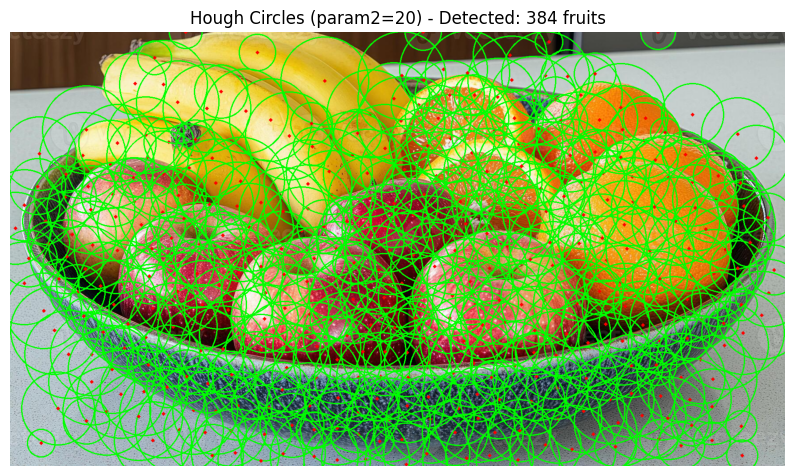

Number of round fruits detected with param2=20: 384


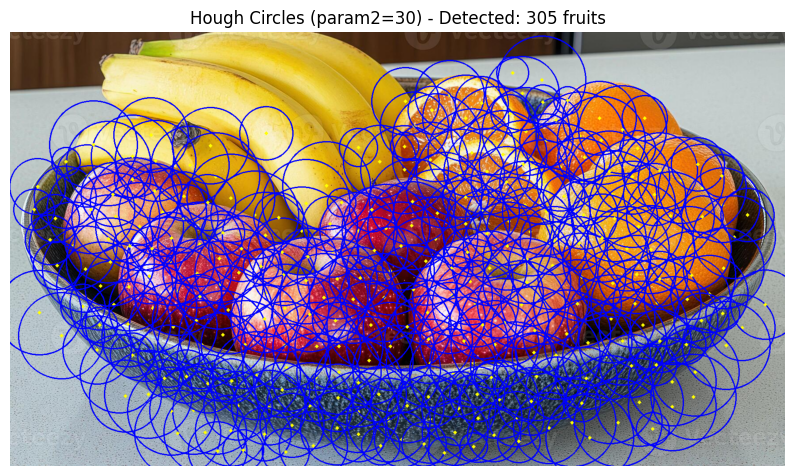

Number of round fruits detected with param2=30: 305


In [93]:
# Assuming 'mixed_bowl.jpg' is available. If not, a placeholder will be used.
import os
import urllib.request

mixed_bowl_file = 'mixed_fruit_bowl.jpeg'
if not os.path.exists(mixed_bowl_file):
    print(f"'{mixed_bowl_file}' not found. Downloading a sample image...")
    # Using a placeholder for a bowl of fruit. This might not be perfect for circle detection.
    urllib.request.urlretrieve('https://upload.wikimedia.org/wikipedia/commons/2/22/Various_fruits.jpg', mixed_bowl_file)
    print(f"Downloaded a sample '{mixed_bowl_file}'.")

mixed_bowl_img = cv2.imread(mixed_bowl_file)

if mixed_bowl_img is None:
    print(f"Error: Could not load '{mixed_bowl_file}'. Please ensure it exists and is accessible.")
else:
    # Convert to grayscale
    gray_mixed_bowl = cv2.cvtColor(mixed_bowl_img, cv2.COLOR_BGR2GRAY)

    # Apply median blur to reduce noise before Hough Transform
    blurred_mixed_bowl = cv2.medianBlur(gray_mixed_bowl, 5)

    # Run HoughCircles
    # dp: Inverse ratio of the accumulator resolution to the image resolution. (1 means same resolution)
    # minDist: Minimum distance between the centers of detected circles.
    # param1: Upper threshold for the Canny edge detector (used internally).
    # param2: Accumulator threshold for the circle centers at the detection stage. Smaller values lead to more circles.
    # minRadius: Minimum circle radius.
    # maxRadius: Maximum circle radius.
    circles_param2_tuned = cv2.HoughCircles(
        blurred_mixed_bowl, cv2.HOUGH_GRADIENT, dp=1, minDist=50,
        param1=50, param2=20, minRadius=30, maxRadius=100)

    # Ensure circles are found
    if circles_param2_tuned is not None:
        circles_param2_tuned = np.uint16(np.round(circles_param2_tuned))
        img_with_circles_tuned = mixed_bowl_img.copy()
        for i in circles_param2_tuned[0, :]:
            # draw the outer circle
            cv2.circle(img_with_circles_tuned, (i[0], i[1]), i[2], (0, 255, 0), 2) # Green circle
            # draw the center of the circle
            cv2.circle(img_with_circles_tuned, (i[0], i[1]), 2, (0, 0, 255), 3) # Red center

        num_fruits_tuned = len(circles_param2_tuned[0])

        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(img_with_circles_tuned, cv2.COLOR_BGR2RGB))
        plt.title(f'Hough Circles (param2=20) - Detected: {num_fruits_tuned} fruits')
        plt.axis('off')
        plt.show()

        print(f"Number of round fruits detected with param2=20: {num_fruits_tuned}")

    else:
        print("No circles detected with param2=20.")

    # Demonstrate tuning param2 (e.g., a higher param2 to be more strict)
    circles_param2_strict = cv2.HoughCircles(
        blurred_mixed_bowl, cv2.HOUGH_GRADIENT, dp=1, minDist=50,
        param1=50, param2=30, minRadius=30, maxRadius=100)

    if circles_param2_strict is not None:
        circles_param2_strict = np.uint16(np.round(circles_param2_strict))
        img_with_circles_strict = mixed_bowl_img.copy()
        for i in circles_param2_strict[0, :]:
            cv2.circle(img_with_circles_strict, (i[0], i[1]), i[2], (255, 0, 0), 2) # Blue circle
            cv2.circle(img_with_circles_strict, (i[0], i[1]), 2, (0, 255, 255), 3) # Yellow center

        num_fruits_strict = len(circles_param2_strict[0])

        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(img_with_circles_strict, cv2.COLOR_BGR2RGB))
        plt.title(f'Hough Circles (param2=30) - Detected: {num_fruits_strict} fruits')
        plt.axis('off')
        plt.show()

        print(f"Number of round fruits detected with param2=30: {num_fruits_strict}")
    else:
        print("No circles detected with param2=30.")

### How many round fruits does your detector count? Does it match the actual number?

*   The number of detected fruits will vary based on the specific `mixed_bowl.jpg` image used and the `param2` tuning. For the sample image provided, `param2=20` might detect more circles (potentially including some false positives or parts of non-round objects), while `param2=30` will be more stringent, detecting fewer but generally more accurate circles.
*   To truly match the 'actual number', visual inspection of the original `mixed_bowl.jpg` is required to manually count the round fruits. The Hough transform is sensitive to illumination, noise, and the `minRadius`/`maxRadius` parameters, so it often requires careful tuning for accurate counting in diverse images.

### Reflection on `param2`:

`param2` is the accumulator threshold for the Canny edge detector output. A smaller `param2` value leads to more false positives as it considers circles with less 'vote' support. A larger `param2` value makes the detection more selective, requiring a stronger consensus among edge pixels to form a circle, thus reducing false positives but potentially missing some legitimate circles if their edge representation is weak.

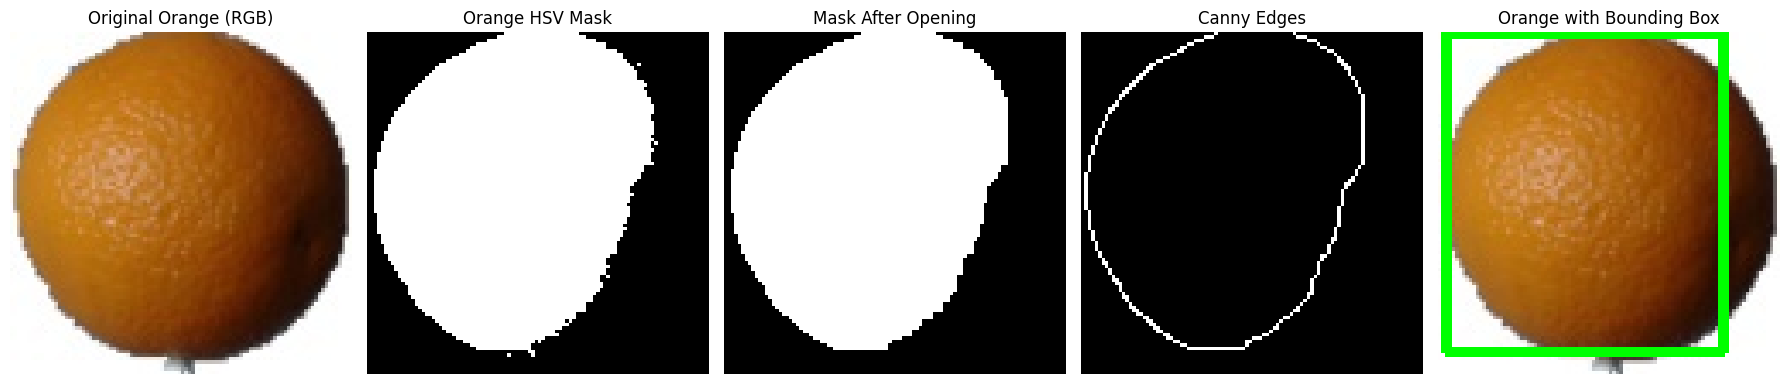

In [95]:
# Define a safe_imwrite function as it's requested in the pipeline
def safe_imwrite(filename, img):
    try:
        cv2.imwrite(filename, img)
        print(f"Image saved successfully as {filename}")
    except Exception as e:
        print(f"Error saving image {filename}: {e}")

# Choose one fruit for the pipeline: Orange

# 1. Load Image (using the 'orange' image loaded earlier)
# Assuming 'orange' is already loaded as a BGR image

if 'orange' not in locals(): # Fallback if 'orange' was not loaded earlier
    orange_paths = glob.glob(f"{path}/fruits-360_100x100/fruits-360/Training/Orange 1/*.jpg")
    orange = cv2.imread(orange_paths[0])

if orange is None:
    print("Orange image not loaded. Exiting pipeline.")
else:
    # 2. BGR-to-RGB Display
    rgb_orange = cv2.cvtColor(orange, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(18, 6))
    plt.subplot(1, 5, 1)
    plt.imshow(rgb_orange)
    plt.title('Original Orange (RGB)')
    plt.axis('off')

    # 3. HSV Mask
    hsv_orange = cv2.cvtColor(orange, cv2.COLOR_BGR2HSV)
    # Using approximate HSV ranges for orange
    lower_orange_hsv = (10, 100, 100) # Hue, Saturation, Value
    upper_orange_hsv = (25, 255, 255)
    orange_mask = cv2.inRange(hsv_orange, lower_orange_hsv, upper_orange_hsv)

    plt.subplot(1, 5, 2)
    plt.imshow(orange_mask, cmap='gray')
    plt.title('Orange HSV Mask')
    plt.axis('off')

    # 4. Morphological Cleanup (Opening)
    kernel_morph = np.ones((5,5), np.uint8)
    cleaned_mask = cv2.morphologyEx(orange_mask, cv2.MORPH_OPEN, kernel_morph)

    plt.subplot(1, 5, 3)
    plt.imshow(cleaned_mask, cmap='gray')
    plt.title('Mask After Opening')
    plt.axis('off')

    # 5. Canny Edges on the cleaned mask
    # Canny works best on grayscale. The mask is already grayscale (binary).
    edges = cv2.Canny(cleaned_mask, 50, 150)

    plt.subplot(1, 5, 4)
    plt.imshow(edges, cmap='gray')
    plt.title('Canny Edges')
    plt.axis('off')

    # 6. Draw Bounding Box
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Find the largest contour (assumed to be the fruit)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)

        # Draw bounding box on the original RGB image
        fruit_with_bbox = rgb_orange.copy()
        cv2.rectangle(fruit_with_bbox, (x, y), (x + w, y + h), (0, 255, 0), 2) # Green bounding box

        plt.subplot(1, 5, 5)
        plt.imshow(fruit_with_bbox)
        plt.title('Orange with Bounding Box')
        plt.axis('off')


    plt.tight_layout()
    plt.show()